# C22 x veNTUre — Stage 1: Data Exploration
**Group 8**

Runs the full pipeline end to end: ingest raw campaign files → label Phase 1
rule breaches → engineer behavioral features → visualize → test significance.


In [2]:
# Mount Drive and point at your data folder.
# LOCAL TESTING: set DATA_DIR to a local path and skip the drive.mount() line.
RUNNING_IN_COLAB = "google.colab" in str(get_ipython())

if RUNNING_IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = "/content/drive/MyDrive/data"
else:
    DATA_DIR = "./data"

print("DATA_DIR =", DATA_DIR)


Mounted at /content/drive
DATA_DIR = /content/drive/MyDrive/data


In [3]:
!pip install -q pandas numpy openpyxl matplotlib scipy

## 1. Ingestion — normalize schema drift, build unified panels

In [4]:

import os, re, glob
import pandas as pd
import numpy as np

FNAME_RE = re.compile(
    r"Campaign[_\s]*(\d+)\s*Data\s*([\d]{1,2}\s*\w+\s*\d{4}).*?"
    r"(Traders[\s_]*only|XAUUSD[\s_]*only)",
    re.IGNORECASE,
)

def parse_filename(path):
    base = os.path.basename(path)
    m = FNAME_RE.search(base)
    if not m:
        cid = re.search(r"Campaign[_\s]*(\d+)", base)
        kind = "Traders_only" if re.search(r"traders", base, re.IGNORECASE) else "XAUUSD_only"
        return (int(cid.group(1)) if cid else None, None, kind)
    campaign_id = int(m.group(1))
    date_str = m.group(2).strip()
    kind = "Traders_only" if "traders" in m.group(3).lower() else "XAUUSD_only"
    try:
        campaign_date = pd.to_datetime(date_str, format="%d %b %Y")
    except ValueError:
        try:
            campaign_date = pd.to_datetime(date_str)
        except Exception:
            campaign_date = pd.NaT
    return campaign_id, campaign_date, kind

ROSTER_COLMAP = {
    "account": "account", "ACCOUNT": "account",
    "email": "email", "EMAIL": "email",
    "ip_address": "ip_address", "IP ADDRESS": "ip_address",
    "telegram_username": "telegram_username",
    "challenge_type_id": "challenge_type_id",
}

def load_roster_file(path):
    df = pd.read_excel(path) if path.lower().endswith(".xlsx") else pd.read_csv(path)
    df = df.rename(columns=ROSTER_COLMAP)
    for col in ["telegram_username", "challenge_type_id"]:
        if col not in df.columns:
            df[col] = np.nan
    df = df[["account", "email", "ip_address", "telegram_username", "challenge_type_id"]]
    campaign_id, campaign_date, _ = parse_filename(path)
    df["campaignId"] = campaign_id
    df["campaignDate"] = campaign_date
    return df

def load_trades_file(path):
    df = pd.read_csv(path)
    for c in ["openDateTime", "closeDateTime"]:
        df[c] = pd.to_datetime(df[c], utc=True).dt.tz_localize(None)
    campaign_id, campaign_date, _ = parse_filename(path)
    df["campaignId"] = campaign_id
    df["campaignDate"] = campaign_date
    check = (df["profit"] + df["commission"] + df["swap"] - df["netProfit"]).abs()
    bad = (check > 0.01).sum()
    if bad:
        print(f"  [warn] {os.path.basename(path)}: {bad} rows where netProfit != profit+commission+swap")
    return df

def load_all_campaigns(folder):
    trader_files, trade_files = [], []
    trader_re = re.compile(r"traders[\s_]*only", re.IGNORECASE)
    trade_re = re.compile(r"xauusd[\s_]*only", re.IGNORECASE)
    for root, _dirs, files in os.walk(folder):
        for fname in files:
            lower = fname.lower()
            if lower.endswith((".xlsx", ".csv")) and trader_re.search(fname):
                trader_files.append(os.path.join(root, fname))
            elif lower.endswith(".csv") and trade_re.search(fname):
                trade_files.append(os.path.join(root, fname))

    roster_frames = [load_roster_file(f) for f in sorted(trader_files)]
    trade_frames = [load_trades_file(f) for f in sorted(trade_files)]

    roster = pd.concat(roster_frames, ignore_index=True) if roster_frames else pd.DataFrame()
    trades = pd.concat(trade_frames, ignore_index=True) if trade_frames else pd.DataFrame()
    if not trades.empty:
        trades = trades.sort_values(["accountId", "openDateTime"]).reset_index(drop=True)

    print(f"Loaded {len(roster_frames)} roster file(s), {len(trade_frames)} trade file(s)")
    if not trades.empty:
        print(f"Trades panel: {len(trades):,} rows | {trades.campaignId.nunique()} campaigns | {trades.accountId.nunique()} unique accounts")
    if not roster.empty:
        print(f"Roster panel: {len(roster):,} rows | {roster.campaignId.nunique()} campaigns | {roster.account.nunique()} unique accounts")
    return trades, roster

trades, roster = load_all_campaigns(DATA_DIR)


Loaded 34 roster file(s), 34 trade file(s)
Trades panel: 46,520 rows | 34 campaigns | 502 unique accounts
Roster panel: 15,878 rows | 34 campaigns | 501 unique accounts


## 2. Phase 1 rule-breach labeling

In [5]:

def assign_trade_ideas(trades):
    trades = trades.sort_values(["accountId", "campaignId", "instrument", "side", "openDateTime"]).copy()
    idea_counter = 0
    idea_ids = np.empty(len(trades), dtype=object)
    grp_cols = ["accountId", "campaignId", "instrument", "side"]
    for _, g in trades.groupby(grp_cols, sort=False):
        idx = g.index.to_numpy()
        opens = g["openDateTime"].to_numpy()
        closes = g["closeDateTime"].to_numpy()
        idea_counter += 1
        idea_ids[trades.index.get_loc(idx[0])] = f"idea_{idea_counter}"
        last_close = closes[0]
        for i in range(1, len(idx)):
            gap = (opens[i] - last_close) / np.timedelta64(1, "m")
            if gap > 3:
                idea_counter += 1
            idea_ids[trades.index.get_loc(idx[i])] = f"idea_{idea_counter}"
            last_close = max(last_close, closes[i])
    trades["ideaId"] = idea_ids
    return trades

def rule_a_atlsr(trades):
    g = trades.groupby(["accountId", "campaignId"])["amount"]
    stats = g.agg(min_lot="min", max_lot="max", avg_lot="mean", n_trades="count").reset_index()
    stats["ratio_max_min"] = stats["max_lot"] / stats["min_lot"]
    stats["band_top"] = stats["avg_lot"] * 2
    stats["band_bottom"] = stats["avg_lot"] / 4
    stats["breach_a_ratio"] = stats["ratio_max_min"] > 2
    stats["breach_a_band"] = (stats["max_lot"] > stats["band_top"]) | (stats["min_lot"] < stats["band_bottom"])
    stats["breach_a"] = stats["breach_a_ratio"] | stats["breach_a_band"]
    return stats[["accountId", "campaignId", "min_lot", "max_lot", "avg_lot", "ratio_max_min", "breach_a"]]

def rule_b_antimartingale(trades):
    trades = trades.sort_values(["accountId", "campaignId", "openDateTime"]).copy()
    trades["prior_avg_lot"] = trades.groupby(["accountId", "campaignId"])["amount"].transform(lambda s: s.shift(1).expanding().mean())
    trades["breach_b_trade"] = (trades["amount"] > 2.5 * trades["prior_avg_lot"]).fillna(False)
    acct = trades.groupby(["accountId", "campaignId"])["breach_b_trade"].any().reset_index().rename(columns={"breach_b_trade": "breach_b"})
    return trades, acct

def rule_c_profit_distribution(trades_with_ideas):
    idea_profit = trades_with_ideas.groupby(["accountId", "campaignId", "ideaId"])["netProfit"].sum().reset_index()
    total_profit = trades_with_ideas.groupby(["accountId", "campaignId"])["netProfit"].sum().reset_index().rename(columns={"netProfit": "total_realized_profit"})
    merged = idea_profit.merge(total_profit, on=["accountId", "campaignId"])
    merged["pct_of_total"] = np.where(merged["total_realized_profit"] > 0, merged["netProfit"] / merged["total_realized_profit"], np.nan)
    merged["idea_breach_c"] = merged["pct_of_total"] > 0.30
    acct = merged.groupby(["accountId", "campaignId"])["idea_breach_c"].any().reset_index().rename(columns={"idea_breach_c": "breach_c"})
    return merged, acct

def rule_grid_averaging(trades):
    trades = trades.sort_values(["accountId", "campaignId", "instrument", "side", "openDateTime"]).copy()
    trades["grid_flag"] = False
    grp_cols = ["accountId", "campaignId", "instrument", "side"]
    for _, g in trades.groupby(grp_cols, sort=False):
        opens = g["openDateTime"].to_numpy()
        prices = g["openPrice"].to_numpy()
        is_buy = g["side"].iloc[0] == "BUY"
        n = len(g)
        if n < 3:
            continue
        window_idx = []
        for i in range(n):
            window_idx.append(i)
            while (opens[i] - opens[window_idx[0]]) / np.timedelta64(1, "s") > 30:
                window_idx.pop(0)
            if len(window_idx) >= 3:
                wp = prices[window_idx]
                worsening = np.all(np.diff(wp) < 0) if is_buy else np.all(np.diff(wp) > 0)
                if worsening:
                    idxs = g.index[window_idx]
                    trades.loc[idxs, "grid_flag"] = True
    acct = trades.groupby(["accountId", "campaignId"])["grid_flag"].any().reset_index().rename(columns={"grid_flag": "breach_grid_soft"})
    return trades, acct

def build_breach_summary(trades):
    trades_ideas = assign_trade_ideas(trades)
    a = rule_a_atlsr(trades)
    trades_b, b = rule_b_antimartingale(trades)
    _, c = rule_c_profit_distribution(trades_ideas)
    trades_grid, grid = rule_grid_averaging(trades)
    summary = a.merge(b, on=["accountId", "campaignId"], how="outer")
    summary = summary.merge(c, on=["accountId", "campaignId"], how="outer")
    summary = summary.merge(grid, on=["accountId", "campaignId"], how="outer")
    summary["hard_breach"] = summary[["breach_a", "breach_b", "breach_c"]].fillna(False).any(axis=1)
    summary["any_breach"] = summary[["hard_breach", "breach_grid_soft"]].fillna(False).any(axis=1)
    return summary, trades_ideas

breach_summary, trades_ideas = build_breach_summary(trades)
print(breach_summary[["breach_a","breach_b","breach_c","breach_grid_soft","hard_breach","any_breach"]].mean().round(3))


breach_a            0.301
breach_b            0.185
breach_c            0.297
breach_grid_soft    0.000
hard_breach         0.500
any_breach          0.500
dtype: float64


## 3. Behavioral feature engineering

In [6]:

def flag_revenge_and_streak(trades):
    trades = trades.sort_values(["accountId", "campaignId", "openDateTime"]).copy()
    out_revenge = np.zeros(len(trades), dtype=bool)
    out_streak = np.zeros(len(trades), dtype=bool)
    for _, g in trades.groupby(["accountId", "campaignId"], sort=False):
        idx = g.index.to_numpy()
        if len(idx) < 2:
            continue
        net = g["netProfit"].to_numpy()
        amt = g["amount"].to_numpy()
        opens = g["openDateTime"].to_numpy()
        closes = g["closeDateTime"].to_numpy()
        gaps_min = (opens[1:] - closes[:-1]) / np.timedelta64(1, "m")
        median_gap = np.nanmedian(gaps_min[gaps_min >= 0]) if len(gaps_min) else np.nan
        consec_wins = 0
        for i in range(1, len(idx)):
            prev_loss = net[i-1] < 0
            lot_up = amt[i] > amt[i-1]
            fast_reentry = (not np.isnan(median_gap) and gaps_min[i-1] >= 0 and gaps_min[i-1] < median_gap)
            if prev_loss and lot_up and fast_reentry:
                out_revenge[trades.index.get_loc(idx[i])] = True
            if net[i-1] > 0:
                consec_wins += 1
            else:
                consec_wins = 0
            if consec_wins >= 2 and lot_up:
                out_streak[trades.index.get_loc(idx[i])] = True
    trades["revenge_flag"] = out_revenge
    trades["streak_up_lot_flag"] = out_streak
    return trades

def size_escalation(trades):
    trades = trades.sort_values(["accountId", "campaignId", "openDateTime"]).copy()
    trades["cum_netProfit"] = trades.groupby(["accountId", "campaignId"])["netProfit"].cumsum()
    def corr_or_nan(g):
        if len(g) < 3 or g["amount"].std() == 0 or g["cum_netProfit"].std() == 0:
            return np.nan
        return g["amount"].corr(g["cum_netProfit"])
    result = trades.groupby(["accountId", "campaignId"]).apply(corr_or_nan, include_groups=False).reset_index(name="size_vs_cumpnl_corr")
    result["size_escalation_flag"] = result["size_vs_cumpnl_corr"] < -0.3
    return result

def reverse_profit_gap(trades):
    g = trades.groupby(["accountId", "campaignId"]).agg(
        total_netProfit=("netProfit", "sum"),
        total_reverseProfit=("reverseProfit", "sum"),
        n_trades=("netProfit", "count"),
    ).reset_index()
    g["reverse_gap"] = g["total_reverseProfit"] - g["total_netProfit"]
    return g

def dropout_after_breach(breach_summary, roster):
    campaign_dates = roster[["campaignId", "campaignDate"]].drop_duplicates().sort_values("campaignDate")
    campaign_order = campaign_dates["campaignId"].tolist()
    next_campaign = {c: campaign_order[i+1] for i, c in enumerate(campaign_order[:-1])}
    roster_sets = {c: set(roster.loc[roster.campaignId == c, "account"]) for c in campaign_order}
    rows = []
    for _, row in breach_summary.iterrows():
        acc, camp = row["accountId"], row["campaignId"]
        if camp not in next_campaign:
            continue
        nxt = next_campaign[camp]
        rows.append({
            "accountId": acc, "campaignId": camp,
            "hard_breach": row["hard_breach"],
            "appeared_next_campaign": acc in roster_sets.get(nxt, set()),
        })
    return pd.DataFrame(rows)

trades = flag_revenge_and_streak(trades)
esc = size_escalation(trades)
rev = reverse_profit_gap(trades)
acct_features = esc.merge(rev, on=["accountId", "campaignId"], how="outer")
trade_flags = trades.groupby(["accountId", "campaignId"]).agg(
    n_revenge_trades=("revenge_flag", "sum"),
    n_streak_up_trades=("streak_up_lot_flag", "sum"),
    n_trades=("revenge_flag", "size"),
).reset_index()
acct_features = acct_features.merge(trade_flags, on=["accountId", "campaignId"], how="outer")
acct_features = acct_features.merge(breach_summary[["accountId","campaignId","hard_breach","breach_a","breach_b","breach_c"]], on=["accountId","campaignId"], how="left")

dropout_df = dropout_after_breach(breach_summary, roster)

print("Revenge trading rate (>=1 revenge trade):", (acct_features.n_revenge_trades > 0).mean().round(3))
print("Win-streak sizing rate (>=1 streak-up trade):", (acct_features.n_streak_up_trades > 0).mean().round(3))
print("Size escalation flag rate:", acct_features.size_escalation_flag.mean().round(3))
print("Mean reverse_gap:", acct_features.reverse_gap.mean().round(2))


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Revenge trading rate (>=1 revenge trade): 0.179
Win-streak sizing rate (>=1 streak-up trade): 0.112
Size escalation flag rate: 0.194
Mean reverse_gap: 32.23


## 4. Visualizations

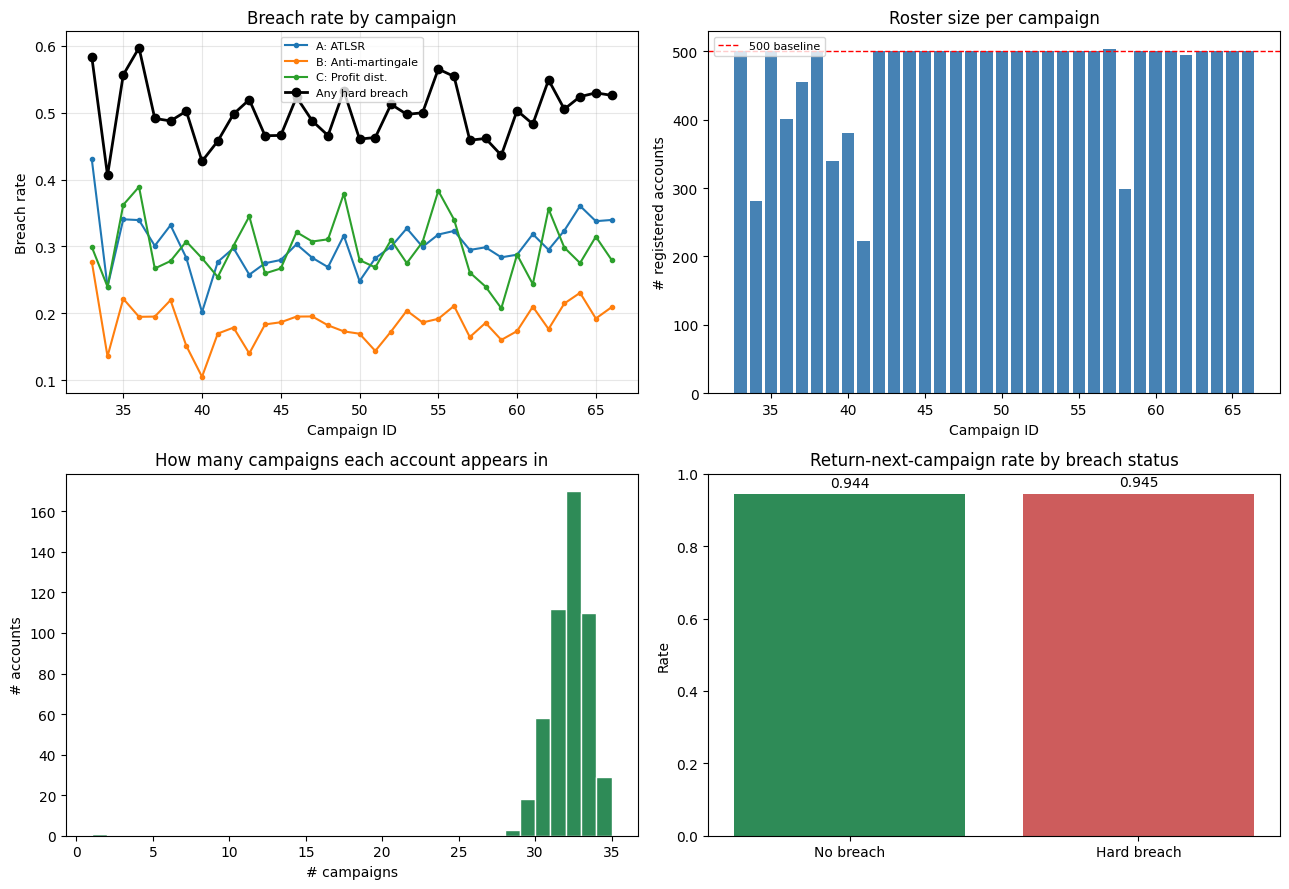

In [7]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# breach rates over campaign sequence
bc = breach_summary.groupby("campaignId")[["breach_a","breach_b","breach_c","hard_breach"]].mean()
axes[0,0].plot(bc.index, bc["breach_a"], marker="o", label="A: ATLSR", ms=3)
axes[0,0].plot(bc.index, bc["breach_b"], marker="o", label="B: Anti-martingale", ms=3)
axes[0,0].plot(bc.index, bc["breach_c"], marker="o", label="C: Profit dist.", ms=3)
axes[0,0].plot(bc.index, bc["hard_breach"], marker="o", label="Any hard breach", lw=2, color="black")
axes[0,0].set_title("Breach rate by campaign")
axes[0,0].set_xlabel("Campaign ID"); axes[0,0].set_ylabel("Breach rate")
axes[0,0].legend(fontsize=8); axes[0,0].grid(alpha=0.3)

# roster size over campaigns
rsize = roster.groupby("campaignId").size()
axes[0,1].bar(rsize.index, rsize.values, color="steelblue")
axes[0,1].axhline(500, color="red", ls="--", lw=1, label="500 baseline")
axes[0,1].set_title("Roster size per campaign")
axes[0,1].set_xlabel("Campaign ID"); axes[0,1].set_ylabel("# registered accounts")
axes[0,1].legend(fontsize=8)

# panel persistence histogram
overlap = roster.groupby("account")["campaignId"].nunique()
axes[1,0].hist(overlap, bins=range(1, overlap.max()+2), color="seagreen", edgecolor="white")
axes[1,0].set_title("How many campaigns each account appears in")
axes[1,0].set_xlabel("# campaigns"); axes[1,0].set_ylabel("# accounts")

# dropout rate by breach status
dr = dropout_df.groupby("hard_breach")["appeared_next_campaign"].mean()
axes[1,1].bar(["No breach","Hard breach"], dr.values, color=["seagreen","indianred"])
axes[1,1].set_ylim(0,1)
axes[1,1].set_title("Return-next-campaign rate by breach status")
axes[1,1].set_ylabel("Rate")
for i, v in enumerate(dr.values):
    axes[1,1].text(i, v+0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.savefig("stage1_overview.png", dpi=150)
plt.show()


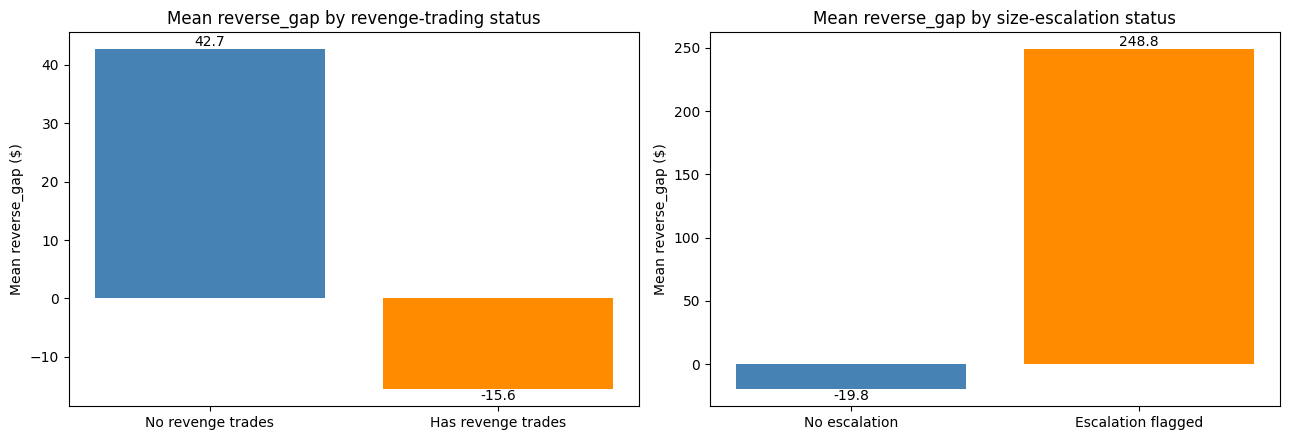

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# revenge trading vs reverse_gap
rev_grp = acct_features.assign(has_revenge=acct_features.n_revenge_trades > 0).groupby("has_revenge")["reverse_gap"].mean()
axes[0].bar(["No revenge trades","Has revenge trades"], rev_grp.values, color=["steelblue","darkorange"])
axes[0].set_title("Mean reverse_gap by revenge-trading status")
axes[0].set_ylabel("Mean reverse_gap ($)")
for i, v in enumerate(rev_grp.values):
    axes[0].text(i, v, f"{v:.1f}", ha="center", va="bottom" if v>=0 else "top")

# escalation vs reverse_gap
esc_grp = acct_features.groupby("size_escalation_flag")["reverse_gap"].mean()
axes[1].bar(["No escalation","Escalation flagged"], esc_grp.values, color=["steelblue","darkorange"])
axes[1].set_title("Mean reverse_gap by size-escalation status")
axes[1].set_ylabel("Mean reverse_gap ($)")
for i, v in enumerate(esc_grp.values):
    axes[1].text(i, v, f"{v:.1f}", ha="center", va="bottom" if v>=0 else "top")

plt.tight_layout()
plt.savefig("stage1_behavior_vs_reversegap.png", dpi=150)
plt.show()


## 5. Statistical significance testing\n\nDon't just eyeball the bar charts above — test whether these differences are real.

In [ ]:

from scipy import stats

def sig_label(p, alpha=0.05):
    return "SIGNIFICANT" if p < alpha else "NOT significant"

def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled_std = np.sqrt(((n1-1)*g1.std(ddof=1)**2 + (n2-1)*g2.std(ddof=1)**2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_std if pooled_std > 0 else np.nan

def interpret_d(d):
    ad = abs(d)
    if ad < 0.2: return "negligible"
    if ad < 0.5: return "small"
    if ad < 0.8: return "medium"
    return "large"

# Bonferroni correction: we are running 6 independent hypothesis tests in this
# section, so the naive alpha=0.05 threshold inflates false-positive risk.
N_TESTS = 6
ALPHA_RAW = 0.05
ALPHA_BONF = ALPHA_RAW / N_TESTS
print(f"Running {N_TESTS} tests. Raw alpha=0.05, Bonferroni-corrected alpha={ALPHA_BONF:.4f}")
print()

results = []

print("=== 1. Dropout rate: hard breach vs no breach (chi-square test) ===")
ct = pd.crosstab(dropout_df.hard_breach, dropout_df.appeared_next_campaign)
chi2, p, dof, exp = stats.chi2_contingency(ct)
print(ct)
print("chi2=%.3f, p=%.4f  ->  %s at Bonferroni alpha=%.4f" % (chi2, p, sig_label(p, ALPHA_BONF), ALPHA_BONF))
results.append(("Dropout ~ hard_breach", "chi-square", chi2, p, None, None))

print()
print("=== 2. reverse_gap: revenge traders vs non-revenge traders (t-test) ===")
g1 = acct_features.loc[acct_features.n_revenge_trades > 0, "reverse_gap"].dropna()
g0 = acct_features.loc[acct_features.n_revenge_trades == 0, "reverse_gap"].dropna()
t, p = stats.ttest_ind(g1, g0, equal_var=False)
d = cohens_d(g1, g0)
print("n_revenge=%d, n_non_revenge=%d, mean_diff=%.2f" % (len(g1), len(g0), g1.mean()-g0.mean()))
print("t=%.3f, p=%.4f, Cohen's d=%.3f (%s)  ->  %s at Bonferroni alpha=%.4f" % (t, p, d, interpret_d(d), sig_label(p, ALPHA_BONF), ALPHA_BONF))
results.append(("reverse_gap ~ revenge_flag", "t-test", t, p, d, interpret_d(d)))

print()
print("=== 3. reverse_gap: size-escalation flagged vs not (t-test) ===")
g1 = acct_features.loc[acct_features.size_escalation_flag == True, "reverse_gap"].dropna()
g0 = acct_features.loc[acct_features.size_escalation_flag == False, "reverse_gap"].dropna()
t, p = stats.ttest_ind(g1, g0, equal_var=False)
d = cohens_d(g1, g0)
print("n_escalation=%d, n_not=%d, mean_diff=%.2f" % (len(g1), len(g0), g1.mean()-g0.mean()))
print("t=%.3f, p=%.4f, Cohen's d=%.3f (%s)  ->  %s at Bonferroni alpha=%.4f" % (t, p, d, interpret_d(d), sig_label(p, ALPHA_BONF), ALPHA_BONF))
results.append(("reverse_gap ~ size_escalation", "t-test", t, p, d, interpret_d(d)))

print()
print("=== 4. reverse_gap: win-streak sizing flagged vs not (t-test) ===")
g1 = acct_features.loc[acct_features.n_streak_up_trades > 0, "reverse_gap"].dropna()
g0 = acct_features.loc[acct_features.n_streak_up_trades == 0, "reverse_gap"].dropna()
t, p = stats.ttest_ind(g1, g0, equal_var=False)
d = cohens_d(g1, g0)
print("n_streak=%d, n_not=%d, mean_diff=%.2f" % (len(g1), len(g0), g1.mean()-g0.mean()))
print("t=%.3f, p=%.4f, Cohen's d=%.3f (%s)  ->  %s at Bonferroni alpha=%.4f" % (t, p, d, interpret_d(d), sig_label(p, ALPHA_BONF), ALPHA_BONF))
results.append(("reverse_gap ~ win_streak_sizing", "t-test", t, p, d, interpret_d(d)))

print()
print("=== 5. ATLSR breach rate vs trade count (does overtrading predict breach?) ===")
merged = breach_summary.merge(trades.groupby(["accountId","campaignId"]).size().reset_index(name="n_trades"), on=["accountId","campaignId"])
corr, p = stats.pointbiserialr(merged["breach_a"], merged["n_trades"])
print(f"(test run at account-campaign level, n={len(merged)} -- NOT at the individual-trade level)")
print("point-biserial r=%.3f, p=%.4g  ->  %s at Bonferroni alpha=%.4f" % (corr, p, sig_label(p, ALPHA_BONF), ALPHA_BONF))
results.append(("breach_a ~ n_trades", "point-biserial", corr, p, None, None))

print()
print("=== 6. DECOMPOSING revenge_flag: which component drives the effect? ===")
print("(revenge_flag = lot-up AND fast-re-entry AND prior-loss, all three together.")
print(" Testing lot-up-after-loss alone, and fast-re-entry-after-loss alone, separately.)")

def decompose_revenge(trades):
    trades = trades.sort_values(["accountId", "campaignId", "openDateTime"]).copy()
    out_lotup_only = np.zeros(len(trades), dtype=bool)
    out_fast_only = np.zeros(len(trades), dtype=bool)
    for _, g in trades.groupby(["accountId", "campaignId"], sort=False):
        idx = g.index.to_numpy()
        if len(idx) < 2:
            continue
        net = g["netProfit"].to_numpy()
        amt = g["amount"].to_numpy()
        opens = g["openDateTime"].to_numpy()
        closes = g["closeDateTime"].to_numpy()
        gaps_min = (opens[1:] - closes[:-1]) / np.timedelta64(1, "m")
        median_gap = np.nanmedian(gaps_min[gaps_min >= 0]) if len(gaps_min) else np.nan
        for i in range(1, len(idx)):
            prev_loss = net[i-1] < 0
            lot_up = amt[i] > amt[i-1]
            fast_reentry = (not np.isnan(median_gap) and gaps_min[i-1] >= 0 and gaps_min[i-1] < median_gap)
            if prev_loss and lot_up:
                out_lotup_only[trades.index.get_loc(idx[i])] = True
            if prev_loss and fast_reentry:
                out_fast_only[trades.index.get_loc(idx[i])] = True
    trades["lotup_after_loss"] = out_lotup_only
    trades["fast_reentry_after_loss"] = out_fast_only
    return trades

trades = decompose_revenge(trades)
decomp = trades.groupby(["accountId","campaignId"]).agg(
    has_lotup_after_loss=("lotup_after_loss","any"),
    has_fast_reentry_after_loss=("fast_reentry_after_loss","any"),
).reset_index()
decomp = decomp.merge(acct_features[["accountId","campaignId","reverse_gap"]], on=["accountId","campaignId"], how="left")

for col, label in [("has_lotup_after_loss","Lot-up after loss (regardless of speed)"),
                    ("has_fast_reentry_after_loss","Fast re-entry after loss (regardless of size)")]:
    g1 = decomp.loc[decomp[col]==True, "reverse_gap"].dropna()
    g0 = decomp.loc[decomp[col]==False, "reverse_gap"].dropna()
    t, p = stats.ttest_ind(g1, g0, equal_var=False)
    d = cohens_d(g1, g0)
    print(f"  {label}: n={len(g1)}, mean_diff={g1.mean()-g0.mean():.2f}, t={t:.3f}, p={p:.4f}, d={d:.3f} ({interpret_d(d)})  ->  {sig_label(p, ALPHA_BONF)}")

results_df = pd.DataFrame(results, columns=["test","method","statistic","p_value","cohens_d","effect_size"])
results_df.to_csv(f"{DATA_DIR}/significance_test_results.csv", index=False)
print()
print("Saved significance_test_results.csv")


Running 6 tests. Raw alpha=0.05, Bonferroni-corrected alpha=0.0083

=== 1. Dropout rate: hard breach vs no breach (chi-square test) ===
appeared_next_campaign  False  True 
hard_breach                         
False                     223   3731
True                      215   3728
chi2=0.099, p=0.7534  ->  NOT significant at Bonferroni alpha=0.0083

=== 2. reverse_gap: revenge traders vs non-revenge traders (t-test) ===
n_revenge=1464, n_non_revenge=6701, mean_diff=-58.24
t=-3.792, p=0.0002, Cohen's d=-0.116 (negligible)  ->  SIGNIFICANT at Bonferroni alpha=0.0083

=== 3. reverse_gap: size-escalation flagged vs not (t-test) ===
n_escalation=1581, n_not=6584, mean_diff=268.53
t=24.184, p=0.0000, Cohen's d=0.547 (medium)  ->  SIGNIFICANT at Bonferroni alpha=0.0083

=== 4. reverse_gap: win-streak sizing flagged vs not (t-test) ===
n_streak=916, n_not=7249, mean_diff=-237.79
t=-12.103, p=0.0000, Cohen's d=-0.479 (small)  ->  SIGNIFICANT at Bonferroni alpha=0.0083

=== 5. ATLSR breach rat

## 6. Confound checks — do the headline findings survive stricter scrutiny?\n\nTwo of the results above deserve a second look before being trusted: reverse_gap is mechanically related to -netProfit (fading a bigger loser produces a bigger reverse_gap almost by construction), and the ATLSR-breach/trade-count correlation could partly be a sampling-range artifact rather than genuine behavioral drift. Both are tested properly here.

In [10]:

# --- Check 1: is size_escalation_flag just a proxy for "lost a lot of money"? ---

corr_netprofit_reversegap, p_np = stats.pearsonr(acct_features["total_netProfit"].dropna(),
                                                    acct_features.loc[acct_features["total_netProfit"].notna(), "reverse_gap"])
print(f"Correlation between total_netProfit and reverse_gap: r={corr_netprofit_reversegap:.3f}, p={p_np:.4g}")
print("(A very strong negative correlation here means reverse_gap is largely mechanical: bigger losers")
print(" automatically get a bigger reverse_gap, regardless of WHY they lost.)")
print()

g = acct_features.groupby("size_escalation_flag")["total_netProfit"].agg(["mean","median","count"])
print("total_netProfit by size_escalation_flag (does escalation just mean 'lost more money'?):")
print(g.round(2))
print()

# Partial-correlation-style test: regress reverse_gap on total_netProfit, then test
# whether size_escalation_flag still predicts the RESIDUAL (the part of reverse_gap
# not already explained by raw loss magnitude).
mask = acct_features["total_netProfit"].notna() & acct_features["reverse_gap"].notna()
x = acct_features.loc[mask, "total_netProfit"].to_numpy()
y = acct_features.loc[mask, "reverse_gap"].to_numpy()
slope, intercept = np.polyfit(x, y, 1)
residuals = y - (slope * x + intercept)

flag = acct_features.loc[mask, "size_escalation_flag"].to_numpy()
g1 = residuals[flag == True]
g0 = residuals[flag == False]
t, p = stats.ttest_ind(g1, g0, equal_var=False)
d_resid = cohens_d(pd.Series(g1), pd.Series(g0))

print("=== CONTROLLED TEST: does size_escalation_flag predict reverse_gap AFTER removing")
print("    the linear total_netProfit -> reverse_gap relationship? ===")
print(f"Residual reverse_gap, escalation=True: mean={g1.mean():.2f}, n={len(g1)}")
print(f"Residual reverse_gap, escalation=False: mean={g0.mean():.2f}, n={len(g0)}")
print(f"t={t:.3f}, p={p:.4f}, Cohen's d={d_resid:.3f} ({interpret_d(d_resid)})  ->  {sig_label(p, ALPHA_BONF)}")
print()
if p < ALPHA_BONF and g1.mean() > g0.mean():
    print("VERDICT: size escalation survives as a genuine signal beyond raw loss magnitude.")
elif p < ALPHA_BONF and g1.mean() < g0.mean():
    print("VERDICT: WARNING -- the effect REVERSES direction once loss magnitude is controlled for.")
    print("         The original 'size escalation is great for fading' claim is likely substantially")
    print("         confounded with total loss size and should NOT be reported as-is.")
else:
    print("VERDICT: no significant residual effect once loss magnitude is controlled for --")
    print("         size escalation does not add information beyond total loss size.")


Correlation between total_netProfit and reverse_gap: r=-0.991, p=0
(A very strong negative correlation here means reverse_gap is largely mechanical: bigger losers
 automatically get a bigger reverse_gap, regardless of WHY they lost.)

total_netProfit by size_escalation_flag (does escalation just mean 'lost more money'?):
                        mean  median  count
size_escalation_flag                       
False                 -10.66 -120.94   6584
True                 -152.38 -207.39   1581

=== CONTROLLED TEST: does size_escalation_flag predict reverse_gap AFTER removing
    the linear total_netProfit -> reverse_gap relationship? ===
Residual reverse_gap, escalation=True: mean=-14.09, n=1581
Residual reverse_gap, escalation=False: mean=3.38, n=6584
t=-9.019, p=0.0000, Cohen's d=-0.264 (small)  ->  SIGNIFICANT

VERDICT: WARNING -- the effect REVERSES direction once loss magnitude is controlled for.
         The original 'size escalation is great for fading' claim is likely substanti

In [11]:

# --- Check 2: is the ATLSR-breach vs trade-count correlation a pure sampling artifact? ---
# Proper null: for each account, resample ITS OWN observed lot sizes (not the whole
# population's) with replacement to build a null distribution of what breach rate
# would look like from pure random re-ordering, holding that account's own typical
# lot-size scale fixed. If observed breach rates closely track this within-account
# null, the correlation is likely a sampling artifact, not real behavioral drift.

np.random.seed(42)
N_BOOTSTRAP = 200

account_lots = trades.groupby(["accountId","campaignId"])["amount"].apply(list)

def null_breach_prob(lots, n_sims=N_BOOTSTRAP):
    """Given one account's own observed lot sizes, estimate P(ATLSR breach) if
    those same trades had occurred in a random order / redrawn with replacement
    from THIS account's own lot-size set -- i.e. no real behavioral escalation,
    just resampling noise at this account's own scale."""
    lots = np.array(lots)
    if len(lots) < 2:
        return np.nan
    breaches = 0
    for _ in range(n_sims):
        draw = np.random.choice(lots, size=len(lots), replace=True)
        ratio = draw.max() / draw.min() if draw.min() > 0 else np.nan
        avg = draw.mean()
        band_breach = (draw.max() > avg * 2) or (draw.min() < avg / 4)
        if (not np.isnan(ratio) and ratio > 2) or band_breach:
            breaches += 1
    return breaches / n_sims

# Run on a random subsample of account-campaigns (full population would be slow) --
# stratified across n_trades so every trade-count bucket is represented.
sample_idx = account_lots.reset_index()
sample_idx["n_trades"] = sample_idx["amount"].apply(len)
sample_idx = sample_idx[sample_idx.n_trades >= 2]
sampled_parts = []
for n_val, g in sample_idx.groupby("n_trades"):
    sampled_parts.append(g.sample(min(len(g), 15), random_state=42))
sampled = pd.concat(sampled_parts, ignore_index=True)

sampled["null_breach_prob"] = sampled["amount"].apply(null_breach_prob)
sampled = sampled.merge(breach_summary[["accountId","campaignId","breach_a"]], on=["accountId","campaignId"], how="left")

by_n = sampled.groupby("n_trades").agg(
    null_rate=("null_breach_prob","mean"),
    observed_rate=("breach_a","mean"),
    n_accounts=("breach_a","count"),
).round(3)
print("Within-account bootstrap null vs. observed ATLSR breach rate, by trade count:")
print(by_n)
print()

gap = (by_n["observed_rate"] - by_n["null_rate"]).mean()
print(f"Mean (observed - null) breach rate across trade-count buckets: {gap:+.3f}")
if gap > 0.05:
    print("VERDICT: observed breach rates exceed what pure resampling of the account's own")
    print("         lot sizes would predict -- the trade-count correlation is likely a real")
    print("         behavioral signal, not just a sampling-range artifact.")
elif gap < -0.05:
    print("VERDICT: observed breach rates are LOWER than the resampling null predicts --")
    print("         real traders are more lot-size-consistent than random chance would be.")
    print("         The r=0.254 correlation from Section 4.2 needs reinterpretation, not")
    print("         a simple 'traders lose control' reading.")
else:
    print("VERDICT: observed and null rates are close -- the trade-count correlation is")
    print("         largely explained by the sampling-range artifact, not genuine drift.")


Within-account bootstrap null vs. observed ATLSR breach rate, by trade count:
          null_rate  observed_rate  n_accounts
n_trades                                      
2             0.036          0.067          15
3             0.302          0.467          15
4             0.130          0.200          15
5             0.311          0.400          15
6             0.128          0.200          15
7             0.266          0.333          15
8             0.555          0.600          15
9             0.275          0.333          15
10            0.548          0.667          15
11            0.324          0.400          15
12            0.362          0.400          15
13            0.314          0.400          15
14            0.489          0.533          15
15            0.418          0.467          15
16            0.342          0.400          15
17            0.428          0.467          15
18            0.360          0.400          15
19            0.641          

## 7. Are these behaviors actually distinct, or redundant?\n\nBefore treating size-escalation, revenge trading, and win-streak sizing as three separate Stage 2 features, check whether they're just re-detecting the same underlying trades.

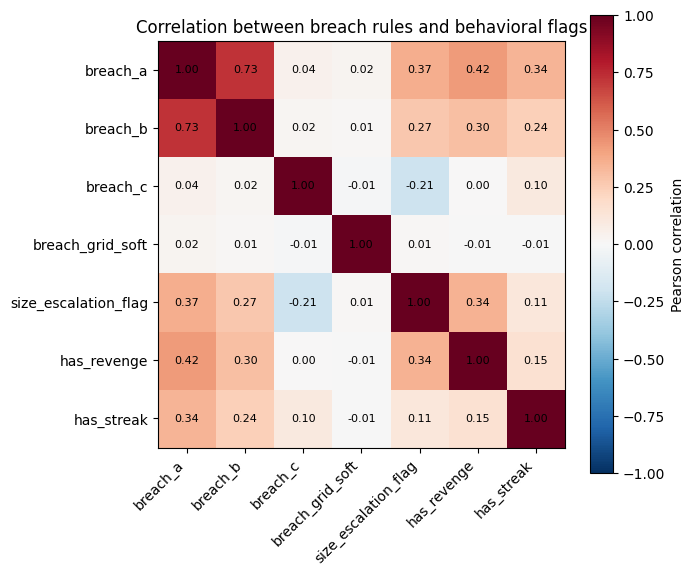

                      breach_a  breach_b  breach_c  breach_grid_soft  \
breach_a                 1.000     0.725     0.041             0.024   
breach_b                 0.725     1.000     0.016             0.013   
breach_c                 0.041     0.016     1.000            -0.010   
breach_grid_soft         0.024     0.013    -0.010             1.000   
size_escalation_flag     0.366     0.273    -0.210             0.012   
has_revenge              0.424     0.300     0.000            -0.007   
has_streak               0.342     0.242     0.096            -0.006   

                      size_escalation_flag  has_revenge  has_streak  
breach_a                             0.366        0.424       0.342  
breach_b                             0.273        0.300       0.242  
breach_c                            -0.210        0.000       0.096  
breach_grid_soft                     0.012       -0.007      -0.006  
size_escalation_flag                 1.000        0.344       0.114  
has

In [12]:

flag_cols = ["breach_a", "breach_b", "breach_c", "breach_grid_soft"]
behavior_cols = ["size_escalation_flag"]

corr_base = breach_summary[["accountId","campaignId"]+flag_cols].merge(
    acct_features[["accountId","campaignId","size_escalation_flag"]], on=["accountId","campaignId"], how="left"
)
corr_base = corr_base.merge(
    trades.groupby(["accountId","campaignId"]).agg(
        has_revenge=("revenge_flag","any"),
        has_streak=("streak_up_lot_flag","any"),
    ).reset_index(),
    on=["accountId","campaignId"], how="left"
)

corr_cols = ["breach_a","breach_b","breach_c","breach_grid_soft","size_escalation_flag","has_revenge","has_streak"]
corr_matrix = corr_base[corr_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, label="Pearson correlation")
plt.title("Correlation between breach rules and behavioral flags")
plt.tight_layout()
plt.savefig("stage1_correlation_heatmap.png", dpi=150)
plt.show()

print(corr_matrix.round(3))


## 8. Per-trader longitudinal trend — does an individual's behavior change across their own campaign history?\n\nThis uses the panel structure (most accounts appear in 30+ of the 34 campaigns) to ask a question a cross-sectional analysis can't: does an account's breach tendency drift over repeated attempts?

Accounts with >=10 campaign appearances: 493
Mean slope (breach-rate trend per additional campaign): 0.00166
One-sample t-test (is the average trend different from zero?): t=1.230, p=0.2192  ->  NOT significant
Accounts trending toward FEWER breaches over time: 240 (48.7%)
Accounts trending toward MORE breaches over time: 252 (51.1%)


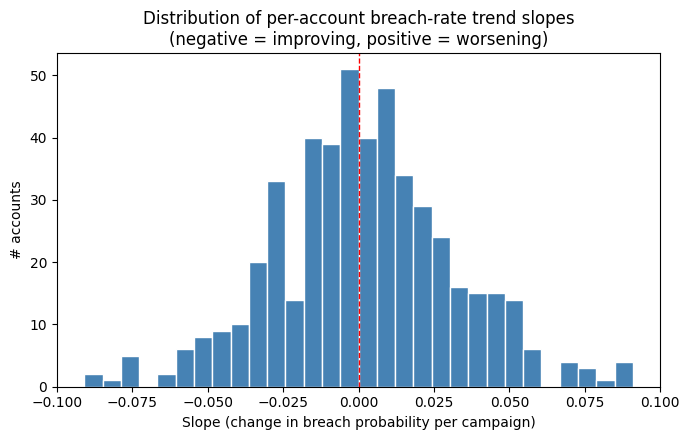

In [13]:

# For accounts with >= 10 campaign appearances, regress hard_breach (0/1) on
# their own campaign sequence number (1st, 2nd, 3rd... campaign they took part
# in) and look at the distribution of slopes across accounts.

merged_seq = breach_summary.merge(roster[["account","campaignId","campaignDate"]].drop_duplicates(),
                                    left_on=["accountId","campaignId"], right_on=["account","campaignId"], how="left")
merged_seq = merged_seq.sort_values(["accountId","campaignDate"])
merged_seq["seq_num"] = merged_seq.groupby("accountId").cumcount() + 1

slopes = []
for acc, g in merged_seq.groupby("accountId"):
    if len(g) < 10:
        continue
    x = g["seq_num"].to_numpy(dtype=float)
    y = g["hard_breach"].to_numpy(dtype=float)
    if x.std() == 0:
        continue
    slope, intercept, r, p, se = stats.linregress(x, y)
    slopes.append({"accountId": acc, "n_campaigns": len(g), "slope": slope, "p_value": p})

slopes_df = pd.DataFrame(slopes)
print(f"Accounts with >=10 campaign appearances: {len(slopes_df)}")

if len(slopes_df) == 0:
    print("No accounts qualify (need >=10 campaign appearances each) — skipping trend test.")
    print("This is expected on small/partial data samples; the full 34-campaign run should have plenty.")
else:
    print(f"Mean slope (breach-rate trend per additional campaign): {slopes_df.slope.mean():.5f}")

    t, p = stats.ttest_1samp(slopes_df["slope"], 0)
    print(f"One-sample t-test (is the average trend different from zero?): t={t:.3f}, p={p:.4f}  ->  {sig_label(p)}")

    n_improving = (slopes_df.slope < 0).sum()
    n_worsening = (slopes_df.slope > 0).sum()
    print(f"Accounts trending toward FEWER breaches over time: {n_improving} ({n_improving/len(slopes_df):.1%})")
    print(f"Accounts trending toward MORE breaches over time: {n_worsening} ({n_worsening/len(slopes_df):.1%})")

    fig, ax = plt.subplots(figsize=(7,4.5))
    ax.hist(slopes_df.slope, bins=30, color="steelblue", edgecolor="white")
    ax.axvline(0, color="red", ls="--", lw=1)
    ax.set_title("Distribution of per-account breach-rate trend slopes\n(negative = improving, positive = worsening)")
    ax.set_xlabel("Slope (change in breach probability per campaign)")
    ax.set_ylabel("# accounts")
    plt.tight_layout()
    plt.savefig("stage1_longitudinal_trend.png", dpi=150)
    plt.show()

    slopes_df.to_csv(f"{DATA_DIR}/trader_breach_trend.csv", index=False)


## 9. Business value quantification\n\nTranslate the statistical findings into an estimated dollar opportunity, since this is what determines whether the finding is actually useful to C22, not just statistically real.

In [14]:

total_reverse_gap_all = acct_features["reverse_gap"].sum()
total_reverse_gap_escalation = acct_features.loc[acct_features.size_escalation_flag == True, "reverse_gap"].sum()
total_reverse_gap_non_escalation = total_reverse_gap_all - total_reverse_gap_escalation
n_escalation_accounts = acct_features.size_escalation_flag.sum()
n_total_accounts = len(acct_features)

pct_of_accounts_escalation = n_escalation_accounts / n_total_accounts
pct_of_reverse_gap_from_escalation = total_reverse_gap_escalation / total_reverse_gap_all if total_reverse_gap_all != 0 else np.nan

print(f"Total reverse_gap across all account-campaigns: ${total_reverse_gap_all:,.2f}")
print(f"Total reverse_gap from size-escalation-flagged accounts ({pct_of_accounts_escalation:.1%} of accounts): ${total_reverse_gap_escalation:,.2f}")
print(f"Total reverse_gap from all OTHER accounts ({1-pct_of_accounts_escalation:.1%} of accounts): ${total_reverse_gap_non_escalation:,.2f}")
print()

if total_reverse_gap_non_escalation < 0:
    print(f"=> The non-escalation group has a NEGATIVE aggregate reverse_gap: fading")
    print(f"   this group would lose money on average. Virtually all of the fading")
    print(f"   opportunity in this dataset is concentrated in the size-escalation-flagged")
    print(f"   {pct_of_accounts_escalation:.0%} of accounts. This means fading should be a TARGETED")
    print(f"   strategy conditioned on the escalation signal, not a blanket approach.")
else:
    print(f"=> Size-escalation-flagged accounts ({pct_of_accounts_escalation:.0%} of accounts) contribute")
    print(f"   {pct_of_reverse_gap_from_escalation:.0%} of total fading opportunity — disproportionate")
    print(f"   value concentration, worth prioritizing in a targeted fading strategy.")
print()

avg_campaigns_per_month = 34 / 5  # campaigns 33-66 span roughly Feb-Jun 2026
projected_monthly_reverse_gap = (total_reverse_gap_escalation / 34) * avg_campaigns_per_month
print(f"Rough projection: if this rate holds, escalation-flagged trades alone represent")
print(f"~${projected_monthly_reverse_gap:,.0f} of fading opportunity per month at current campaign volume")
print(f"(illustrative only — assumes stable rates and campaign frequency; NOT a forecast)")


Total reverse_gap across all account-campaigns: $263,155.58
Total reverse_gap from size-escalation-flagged accounts (19.4% of accounts): $393,291.52
Total reverse_gap from all OTHER accounts (80.6% of accounts): $-130,135.93

=> The non-escalation group has a NEGATIVE aggregate reverse_gap: fading
   this group would lose money on average. Virtually all of the fading
   opportunity in this dataset is concentrated in the size-escalation-flagged
   19% of accounts. This means fading should be a TARGETED
   strategy conditioned on the escalation signal, not a blanket approach.

Rough projection: if this rate holds, escalation-flagged trades alone represent
~$78,658 of fading opportunity per month at current campaign volume
(illustrative only — assumes stable rates and campaign frequency; NOT a forecast)


## 10. Export panels for Stage 2 / memo

In [15]:

trades.to_csv(f"{DATA_DIR}/trades_panel.csv", index=False)
roster.to_csv(f"{DATA_DIR}/roster_panel.csv", index=False)
breach_summary.to_csv(f"{DATA_DIR}/breach_summary.csv", index=False)
acct_features.to_csv(f"{DATA_DIR}/behavioral_features.csv", index=False)
dropout_df.to_csv(f"{DATA_DIR}/dropout_after_breach.csv", index=False)
slopes_df.to_csv(f"{DATA_DIR}/trader_breach_trend.csv", index=False)
print("Saved all panels to", DATA_DIR)


Saved all panels to /content/drive/MyDrive/data
